# K-Nearest Neighbours Fraud Classification

This notebook is part of the ordered PaySim fraud-detection workflow. See the project README for data setup, evaluation context, and limitations.

## 1. Imports


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42


# 2. Load processed data

We load X_train, X_test, y_train and y_test from ../data/processed.


In [ ]:
DATA_DIR = Path('../data/processed')

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

print("Data loaded successfully.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# 3. Logistic Regression baseline

We train the shared baseline model.


In [25]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.93):
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test)
        y_scores = y_pred

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
        "PR-AUC": average_precision_score(y_test, y_scores)
    }

    print(f"\n{model_name} Classification Report at threshold {threshold}")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return results



Logistic Regression Classification Report at threshold 0.93
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     70651
           1       0.07      0.42      0.12        92

    accuracy                           0.99     70743
   macro avg       0.54      0.71      0.56     70743
weighted avg       1.00      0.99      0.99     70743



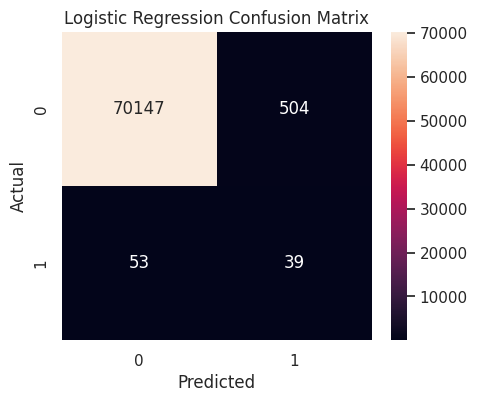

In [26]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train, y_train)

log_reg_results = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_test,
    y_test
)


# 4. Main model

Now we train the assigned model.



K-Nearest Neighbours Classification Report at threshold 0.93
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70651
           1       0.13      0.49      0.20        92

    accuracy                           0.99     70743
   macro avg       0.56      0.74      0.60     70743
weighted avg       1.00      0.99      1.00     70743



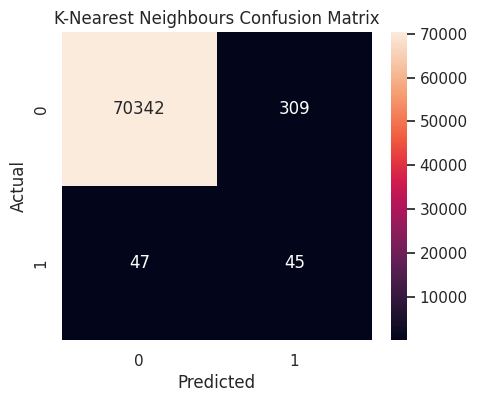

In [27]:
unique_model_name = "K-Nearest Neighbours"

rus = RandomUnderSampler(
    sampling_strategy=0.2,
    random_state=RANDOM_STATE
)

X_train_knn, y_train_knn = rus.fit_resample(X_train, y_train)

unique_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski",
    p=2
)

unique_model.fit(X_train_knn, y_train_knn)

unique_model_results = evaluate_model(
    unique_model_name,
    unique_model,
    X_test,
    y_test
)


## 5. Decision Threshold

The threshold below is an exploratory operating point evaluated on the test set. It must be selected on validation data before these threshold-dependent metrics can be treated as an unbiased final estimate.


# 6. Model evaluation

We plot ROC and PR curves.


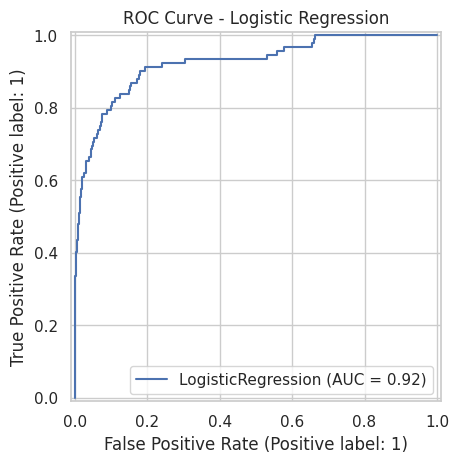

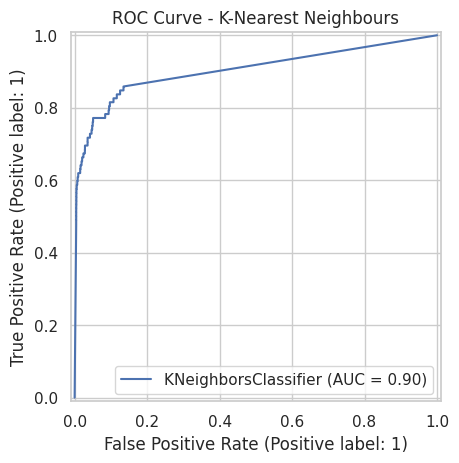

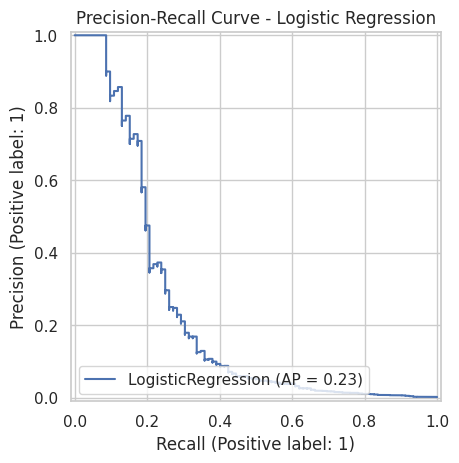

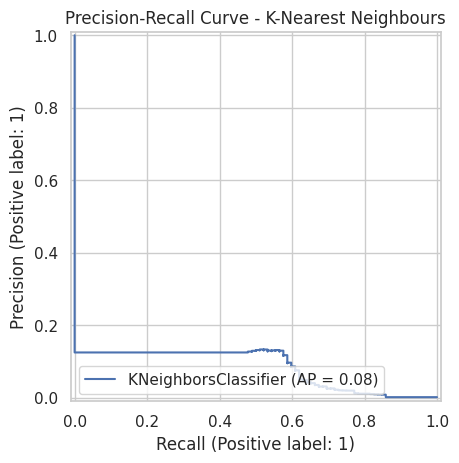

In [29]:
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_estimator(unique_model, X_test, y_test)
plt.title(f"ROC Curve - {unique_model_name}")
plt.show()

PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_estimator(unique_model, X_test, y_test)
plt.title(f"Precision-Recall Curve - {unique_model_name}")
plt.show()


# 7. Feature importance or model interpretation

KNN does not give feature importance, so we keep the baseline coefficient check.


,Feature,Coefficient,Abs_Coefficient
10,amount_to_balance_ratio,8.945311,8.945311
6,sender_balance_error,6.886179,6.886179
1,amount,-5.579298,5.579298
8,sender_balance_change,3.485044,3.485044
11,type_CASH_OUT,-2.592467,2.592467
3,newbalanceOrig,-2.251541,2.251541
9,receiver_balance_change,-1.636873,1.636873
7,receiver_balance_error,-1.567655,1.567655
12,type_TRANSFER,-0.922505,0.922505
5,newbalanceDest,-0.777589,0.777589


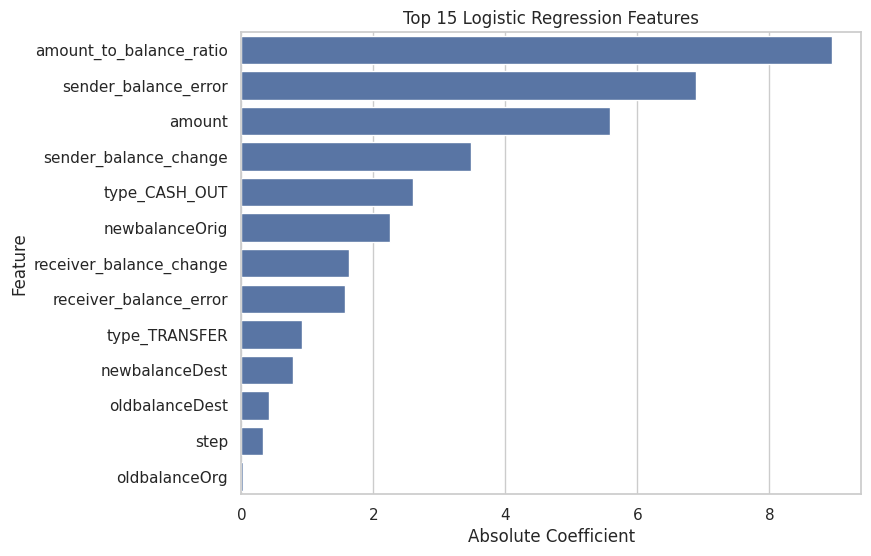

In [30]:
log_reg_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0],
    "Abs_Coefficient": np.abs(log_reg.coef_[0])
}).sort_values(by="Abs_Coefficient", ascending=False)

display(log_reg_importance.head(15))

top_log_reg_features = log_reg_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_log_reg_features["Feature"], top_log_reg_features["Abs_Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 15 Logistic Regression Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 8. Results summary

This table shows how the models performed.


In [28]:
results_df = pd.DataFrame([log_reg_results, unique_model_results])

results_df_rounded = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.93,0.9921,0.0718,0.4239,0.1228,0.9238,0.2337
1,K-Nearest Neighbours,0.93,0.9950,0.1271,0.4891,0.2018,0.9036,0.0822
